# Cell 2 — Load Financial PhraseBank

In [3]:
import kagglehub

path = kagglehub.dataset_download("ankurzing/sentiment-analysis-for-financial-news")

print("Path to dataset files:", path)

import pandas as pd

df_phrasebank = pd.read_csv(
    "/home/kevin/.cache/kagglehub/datasets/ankurzing/sentiment-analysis-for-financial-news/versions/5/all-data.csv",
    encoding="latin-1",
    header=None,
    names=["label", "headline"]
)
df_phrasebank["source"] = "phrasebank"

print(df_phrasebank.shape)
print(df_phrasebank["label"].value_counts())
df_phrasebank.head()

/home/kevin/miniconda3/envs/idea2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/kevin/.cache/kagglehub/datasets/ankurzing/sentiment-analysis-for-financial-news/versions/5
(4846, 3)
label
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


,label,headline,source
0,neutral,"According to Gran , the company has no plans t...",phrasebank
1,neutral,Technopolis plans to develop in stages an area...,phrasebank
2,negative,The international electronic industry company ...,phrasebank
3,positive,With the new production plant the company woul...,phrasebank
4,positive,According to the company 's updated strategy f...,phrasebank


# Cell 3 — Load Twitter Financial News Dataset

In [4]:
from datasets import load_dataset
import pandas as pd
twitter_data = load_dataset("zeroshot/twitter-financial-news-sentiment")

df_twitter = pd.DataFrame(twitter_data["train"])
df_twitter.columns = ["headline", "label"]
df_twitter["label"] = df_twitter["label"].map({0: "bearish", 1: "bullish", 2: "neutral"})

df_twitter["label"] = df_twitter["label"].map({
    "bullish": "positive",
    "bearish": "negative",
    "neutral": "neutral"
})
df_twitter["source"] = "twitter"

print(df_twitter.shape)
print(df_twitter["label"].value_counts())
df_twitter.head()

(9543, 3)
label
neutral     6178
positive    1923
negative    1442
Name: count, dtype: int64


,headline,label,source
0,$BYND - JPMorgan reels in expectations on Beyo...,negative,twitter
1,$CCL $RCL - Nomura points to bookings weakness...,negative,twitter
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",negative,twitter
3,$ESS: BTIG Research cuts to Neutral https://t....,negative,twitter
4,$FNKO - Funko slides after Piper Jaffray PT cu...,negative,twitter


# Cell 4 — Merge and clean both datasets

In [5]:
df_all = pd.concat([df_phrasebank, df_twitter], ignore_index=True)
df_all = df_all.dropna(subset=["headline", "label"])
df_all = df_all.drop_duplicates(subset=["headline"])
df_all = df_all[df_all["headline"].str.len() > 20]  

print(f"Total headlines: {len(df_all)}")
print(df_all["label"].value_counts())
print(df_all["source"].value_counts())

df_all.to_csv("headlines_raw.csv", index=False)
print("Saved to headlines_raw.csv")

Total headlines: 14308
label
neutral     8990
positive    3273
negative    2045
Name: count, dtype: int64
source
twitter       9479
phrasebank    4829
Name: count, dtype: int64
Saved to headlines_raw.csv


# Cell 5 — Download stock price data

In [6]:
import yfinance as yf
import pandas as pd

tickers = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",
    "META", "TSLA", "JPM", "BAC", "GS",
    "JNJ", "PFE", "XOM", "CVX", "WMT",
    "NFLX", "AMD", "INTC", "ORCL", "CRM"
]

df_prices = yf.download(
    tickers,
    start="2019-01-01",
    end="2024-12-31",
    auto_adjust=True
)["Close"]

df_prices = df_prices.dropna(how="all")
df_prices.to_csv("stock_prices.csv")

print(f"Price data shape: {df_prices.shape}")
print(f"Date range: {df_prices.index[0]} → {df_prices.index[-1]}")
df_prices.tail()

[*********************100%***********************]  20 of 20 completed

Price data shape: (1509, 20)
Date range: 2019-01-02 00:00:00 → 2024-12-30 00:00:00


Ticker,AAPL,AMD,AMZN,BAC,CRM,CVX,GOOGL,GS,INTC,JNJ,JPM,META,MSFT,NFLX,NVDA,ORCL,PFE,TSLA,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,
2024-12-23,253.883118,124.599998,225.059998,42.655346,340.675934,135.312317,193.734329,556.436035,20.200001,140.209885,232.399857,597.452820,431.078888,91.144997,139.624252,167.032700,24.497419,430.600006,89.493370,101.857841
2024-12-24,256.797180,126.290001,229.050003,43.131565,342.196014,136.135712,195.207535,568.144104,20.400000,140.769699,236.221329,605.321350,435.119720,93.211998,140.174072,169.274445,24.524935,462.279999,91.801270,101.953667
2024-12-26,257.612701,125.059998,227.050003,43.296783,339.503601,136.268204,194.699890,566.623352,20.440001,140.509094,237.030487,600.938904,433.911438,92.414001,139.884171,169.541046,24.359848,454.130005,91.910240,102.039894
2024-12-27,254.201385,125.190002,223.750000,43.092686,336.254822,136.287125,191.872940,561.700256,20.299999,139.997543,235.109985,597.413086,426.404083,90.754997,136.965118,166.854965,24.414879,431.660004,90.790947,102.030319
2024-12-30,250.829803,122.440002,221.300003,42.674789,333.562378,135.406952,190.359940,559.136414,19.820000,138.347122,233.306488,588.877258,420.758698,90.042999,137.444946,164.830490,24.231445,417.410004,89.711288,101.340401


# Cell 6 — Compute technical indicators

In [7]:
import pandas as pd
import numpy as np

prices = pd.read_csv("stock_prices.csv", index_col=0, parse_dates=True)

def compute_indicators(series):
    df = pd.DataFrame({"close": series}).dropna()
    
    df["return_1d"] = df["close"].pct_change(1)
    df["return_5d"] = df["close"].pct_change(5)
    
    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    df["rsi"] = 100 - (100 / (1 + gain / loss))
    
    ema12 = df["close"].ewm(span=12).mean()
    ema26 = df["close"].ewm(span=26).mean()
    df["macd"] = ema12 - ema26
    df["macd_signal"] = df["macd"].ewm(span=9).mean()
    df["macd_hist"] = df["macd"] - df["macd_signal"]
    
    sma20 = df["close"].rolling(20).mean()
    std20 = df["close"].rolling(20).std()
    df["bb_upper"] = sma20 + 2 * std20
    df["bb_lower"] = sma20 - 2 * std20
    df["bb_position"] = (df["close"] - df["bb_lower"]) / (df["bb_upper"] - df["bb_lower"])
    
    df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)
    
    return df

all_indicators = {}
for ticker in prices.columns:
    all_indicators[ticker] = compute_indicators(prices[ticker])

all_indicators["AAPL"].to_csv("indicators_AAPL.csv")
print("Indicators computed for all tickers")
print(all_indicators["AAPL"].tail())

Indicators computed for all tickers
                 close  return_1d  return_5d        rsi      macd  \
Date                                                                
2024-12-23  253.883118   0.003065   0.016850  73.865369  5.740451   
2024-12-24  256.797180   0.011478   0.018621  76.180634  6.040995   
2024-12-26  257.612701   0.003176   0.044225  76.812074  6.272677   
2024-12-27  254.201385  -0.013242   0.023220  69.300693  6.110582   
2024-12-30  250.829803  -0.013263  -0.008998  58.382063  5.644991   

            macd_signal  macd_hist    bb_upper    bb_lower  bb_position  \
Date                                                                      
2024-12-23     5.198233   0.542218  256.772104  230.619420     0.889534   
2024-12-24     5.366785   0.674210  257.981096  231.929666     0.954555   
2024-12-26     5.547963   0.724713  259.228957  233.064784     0.938226   
2024-12-27     5.660487   0.450095  259.319027  235.029490     0.789307   
2024-12-30     5.657388  -0.01

# Cell 7 — Final data check

In [8]:
print("=== DATASET SUMMARY ===")
print(f"Headlines total:      {len(df_all)}")
print(f"  - Positive:         {(df_all['label']=='positive').sum()}")
print(f"  - Negative:         {(df_all['label']=='negative').sum()}")
print(f"  - Neutral:          {(df_all['label']=='neutral').sum()}")
print(f"\nStock tickers:        {len(prices.columns)}")
print(f"Price history:        {prices.shape[0]} trading days")
print(f"Technical indicators: RSI, MACD, MACD Signal, MACD Hist, BB Position, Returns (1d, 5d)")
print(f"\nFiles saved:")
print(f"  headlines_raw.csv")
print(f"  stock_prices.csv")
print(f"  indicators_AAPL.csv (example)")
print("\n=== READY FOR SENTIMENT EXTRACTION ===")

=== DATASET SUMMARY ===
Headlines total:      14308
  - Positive:         3273
  - Negative:         2045
  - Neutral:          8990

Stock tickers:        20
Price history:        1509 trading days
Technical indicators: RSI, MACD, MACD Signal, MACD Hist, BB Position, Returns (1d, 5d)

Files saved:
  headlines_raw.csv
  stock_prices.csv
  indicators_AAPL.csv (example)

=== READY FOR SENTIMENT EXTRACTION ===


# Cell 8

In [2]:
import requests
import json
import re

def get_ollama_sentiment(headline, model="mistral"):
    prompt = f"""Analyze the financial sentiment of this news headline.
Respond with ONLY a JSON object: {{"positive": float, "negative": float, "neutral": float}}
All three values must sum to 1.0. No explanation, just the JSON.

Headline: {headline}"""

    response = requests.post("http://localhost:11434/api/generate", json={
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": 0.1}
    })

    text = response.json()["response"]
    match = re.search(r'\{.*?\}', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except:
            pass
    return {"positive": 0.33, "negative": 0.33, "neutral": 0.34}

test = "Apple stock surges after record quarterly earnings"
print("Mistral:", get_ollama_sentiment(test, model="mistral"))
print("Llama3: ", get_ollama_sentiment(test, model="llama3"))

Mistral: {'positive': 0.85, 'negative': 0.05, 'neutral': 0.1}
Llama3:  {'positive': 0.8, 'negative': 0.1, 'neutral': 0.1}


# Cell 9 — Run FinBERT on all headlines

In [3]:
import torch
from transformers import pipeline
import pandas as pd
from tqdm import tqdm

df_all = pd.read_csv("headlines_raw.csv")

finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    device=0,
    top_k=None,
    model_kwargs={"use_safetensors": True}
)

def get_finbert_scores(texts, batch_size=64):
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="FinBERT"):
        batch = texts[i:i+batch_size]
        outputs = finbert(batch, truncation=True, max_length=512)
        for out in outputs:
            scores = {d["label"]: d["score"] for d in out}
            results.append({
                "finbert_positive": scores.get("positive", 0),
                "finbert_negative": scores.get("negative", 0),
                "finbert_neutral":  scores.get("neutral", 0)
            })
    return results

finbert_scores = get_finbert_scores(df_all["headline"].tolist())
df_finbert = pd.DataFrame(finbert_scores)
df_finbert.to_csv("sentiment_finbert.csv", index=False)
print(f"Done. Shape: {df_finbert.shape}")
print(df_finbert.head())

/home/kevin/miniconda3/envs/idea2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 4399.05it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
FinBERT: 100%|████████████████████████████████████████████████████████████████████████| 224/224 [01:20<00:00,  2.78it/s]


Done. Shape: (14308, 3)
   finbert_positive  finbert_negative  finbert_neutral
0          0.103407          0.010862         0.885731
1          0.457669          0.008493         0.533838
2          0.007849          0.972056         0.020095
3          0.947900          0.012434         0.039666
4          0.859708          0.008038         0.132254


# Cell 10 — Run Mistral on all headlines

In [4]:
import requests, json, re
from tqdm import tqdm
import pandas as pd

def get_ollama_sentiment(headline, model="mistral"):
    prompt = f"""Analyze the financial sentiment of this news headline.
Respond with ONLY a JSON object: {{"positive": float, "negative": float, "neutral": float}}
All three values must sum to 1.0. No explanation, just the JSON.

Headline: {headline}"""
    try:
        response = requests.post("http://localhost:11434/api/generate", json={
            "model": model,
            "prompt": prompt,
            "stream": False,
            "options": {"temperature": 0.1}
        }, timeout=30)
        text = response.json()["response"]
        match = re.search(r'\{.*?\}', text, re.DOTALL)
        if match:
            return json.loads(match.group())
    except:
        pass
    return {"positive": 0.33, "negative": 0.33, "neutral": 0.34}

df_all = pd.read_csv("headlines_raw.csv")
headlines = df_all["headline"].tolist()

mistral_scores = []
for h in tqdm(headlines, desc="Mistral"):
    s = get_ollama_sentiment(h, model="mistral")
    mistral_scores.append({
        "mistral_positive": s.get("positive", 0.33),
        "mistral_negative": s.get("negative", 0.33),
        "mistral_neutral":  s.get("neutral", 0.34)
    })

pd.DataFrame(mistral_scores).to_csv("sentiment_mistral.csv", index=False)
print(f"Done. {len(mistral_scores)} rows saved.")

Mistral: 100%|██████████████████████████████████████████████████████████████████| 14308/14308 [2:37:12<00:00,  1.52it/s]

Done. 14308 rows saved.


# Cell 11 — Run Llama3 on all headlines

In [5]:
llama3_scores = []
for h in tqdm(headlines, desc="Llama3"):
    s = get_ollama_sentiment(h, model="llama3")
    llama3_scores.append({
        "llama3_positive": s.get("positive", 0.33),
        "llama3_negative": s.get("negative", 0.33),
        "llama3_neutral":  s.get("neutral", 0.34)
    })

pd.DataFrame(llama3_scores).to_csv("sentiment_llama3.csv", index=False)
print(f"Done. {len(llama3_scores)} rows saved.")

Llama3: 100%|███████████████████████████████████████████████████████████████████| 14308/14308 [2:26:57<00:00,  1.62it/s]

Done. 14308 rows saved.


# Cell 12 — Merge all sentiment scores

In [6]:
df_all = pd.read_csv("headlines_raw.csv")
df_fb  = pd.read_csv("sentiment_finbert.csv")
df_mi  = pd.read_csv("sentiment_mistral.csv")
df_ll  = pd.read_csv("sentiment_llama3.csv")

df_sentiment = pd.concat([df_all, df_fb, df_mi, df_ll], axis=1)
df_sentiment.to_csv("sentiment_all.csv", index=False)

print(f"Final shape: {df_sentiment.shape}")
print(df_sentiment.columns.tolist())
print(df_sentiment.head(3))

Final shape: (14308, 12)
['label', 'headline', 'source', 'finbert_positive', 'finbert_negative', 'finbert_neutral', 'mistral_positive', 'mistral_negative', 'mistral_neutral', 'llama3_positive', 'llama3_negative', 'llama3_neutral']
      label                                           headline      source  \
0   neutral  According to Gran , the company has no plans t...  phrasebank   
1   neutral  Technopolis plans to develop in stages an area...  phrasebank   
2  negative  The international electronic industry company ...  phrasebank   

   finbert_positive  finbert_negative  finbert_neutral  mistral_positive  \
0          0.103407          0.010862         0.885731              0.40   
1          0.457669          0.008493         0.533838              0.65   
2          0.007849          0.972056         0.020095              0.10   

   mistral_negative  mistral_neutral  llama3_positive  llama3_negative  \
0              0.30              0.3              0.6              0.3   
1  

# Cell 13 — the fusion dataset builder

In [7]:
import pandas as pd
import numpy as np

df_sentiment = pd.read_csv("sentiment_all.csv")
prices = pd.read_csv("stock_prices.csv", index_col=0, parse_dates=True)

tickers = prices.columns.tolist()

def compute_indicators(series):
    df = pd.DataFrame({"close": series}).dropna()
    df["return_1d"] = df["close"].pct_change(1)
    df["return_5d"] = df["close"].pct_change(5)
    delta = df["close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = -delta.clip(upper=0).rolling(14).mean()
    df["rsi"] = 100 - (100 / (1 + gain / loss))
    ema12 = df["close"].ewm(span=12).mean()
    ema26 = df["close"].ewm(span=26).mean()
    df["macd"] = ema12 - ema26
    df["macd_signal"] = df["macd"].ewm(span=9).mean()
    df["macd_hist"] = df["macd"] - df["macd_signal"]
    sma20 = df["close"].rolling(20).mean()
    std20 = df["close"].rolling(20).std()
    df["bb_position"] = (df["close"] - (sma20 - 2*std20)) / (4*std20)
    df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)
    return df

df_sentiment["date"] = pd.to_datetime(df_sentiment.get("date", pd.Timestamp.today()))

sentiment_cols = [
    "finbert_positive","finbert_negative","finbert_neutral",
    "mistral_positive","mistral_negative","mistral_neutral",
    "llama3_positive","llama3_negative","llama3_neutral"
]

all_fusion = []
for ticker in tickers:
    ind = compute_indicators(prices[ticker]).dropna()
    ind["ticker"] = ticker
    ind["date"] = ind.index
    all_fusion.append(ind)

df_technical = pd.concat(all_fusion, ignore_index=True)
df_technical.to_csv("technical_all.csv", index=False)
print(f"Technical dataset: {df_technical.shape}")
print(df_technical.head(3))

Technical dataset: (29800, 11)
       close  return_1d  return_5d        rsi      macd  macd_signal  \
0  39.244499   0.068335   0.073610  66.969781  0.321433     0.178428   
1  39.527092   0.007201   0.089980  67.614140  0.452608     0.233775   
2  39.546104   0.000481   0.055527  70.653101  0.550047     0.297499   

   macd_hist  bb_position  target ticker       date  
0   0.143004     1.127673       1   AAPL 2019-01-30  
1   0.218833     1.075997       1   AAPL 2019-01-31  
2   0.252548     1.028860       1   AAPL 2019-02-01  


# Cell 14 — Align sentiment with stock data by date

In [14]:
import pandas as pd
import numpy as np

df_sentiment = pd.read_csv("sentiment_all.csv")
df_technical = pd.read_csv("technical_all.csv", parse_dates=["date"])

trading_dates = sorted(df_technical["date"].unique())
n_dates = len(trading_dates)
n_headlines = len(df_sentiment)

df_sentiment["date"] = [
    trading_dates[int(i * n_dates / n_headlines)]
    for i in range(n_headlines)
]

sentiment_cols = [
    "finbert_positive","finbert_negative","finbert_neutral",
    "mistral_positive","mistral_negative","mistral_neutral",
    "llama3_positive","llama3_negative","llama3_neutral"
]

daily_sentiment = df_sentiment.groupby("date")[sentiment_cols].mean().reset_index()
print(f"Daily sentiment rows: {len(daily_sentiment)}")
print(daily_sentiment.head())

df_technical["date"] = pd.to_datetime(df_technical["date"])
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])

df_fusion = df_technical.merge(daily_sentiment, on="date", how="inner")
print(f"\nFusion dataset shape: {df_fusion.shape}")
print(f"Sentiment variance check (finbert_positive): {df_fusion['finbert_positive'].std():.6f}")

for col in sentiment_cols:
    print(f"  {col} — mean: {df_fusion[col].mean():.4f}, std: {df_fusion[col].std():.4f}")

df_fusion = df_fusion.sort_values("date")
cutoff_idx = int(len(df_fusion) * 0.8)
cutoff_date = df_fusion.iloc[cutoff_idx]["date"]

df_train = df_fusion[df_fusion["date"] < cutoff_date].copy()
df_test  = df_fusion[df_fusion["date"] >= cutoff_date].copy()

df_train.to_csv("fusion_train.csv", index=False)
df_test.to_csv("fusion_test.csv", index=False)

print(f"\nTrain: {df_train.shape}, Test: {df_test.shape}")
print(f"Cutoff date: {cutoff_date.date()}")
print(f"Class balance (test): {df_test['target'].value_counts().to_dict()}")

Daily sentiment rows: 1490
        date  finbert_positive  finbert_negative  finbert_neutral  \
0 2019-01-30          0.706276          0.111422         0.182302   
1 2019-01-31          0.941529          0.018822         0.039649   
2 2019-02-01          0.937133          0.017711         0.045156   
3 2019-02-04          0.942072          0.018296         0.039632   
4 2019-02-05          0.924423          0.022572         0.053005   

   mistral_positive  mistral_negative  mistral_neutral  llama3_positive  \
0          0.579000          0.215000         0.206000         0.625000   
1          0.767000          0.103000         0.130000         0.672000   
2          0.744444          0.116667         0.138889         0.722222   
3          0.709000          0.135000         0.156000         0.700000   
4          0.641000          0.163000         0.196000         0.690000   

   llama3_negative  llama3_neutral  
0         0.255000        0.120000  
1         0.204000        0.12400

# Cell 15 — Train and evaluate all models

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import pandas as pd
import numpy as np

df_train = pd.read_csv("fusion_train.csv").dropna()
df_test  = pd.read_csv("fusion_test.csv").dropna()

technical_features = ["return_1d","return_5d","rsi","macd","macd_signal","macd_hist","bb_position"]
finbert_features   = ["finbert_positive","finbert_negative","finbert_neutral"]
mistral_features   = ["mistral_positive","mistral_negative","mistral_neutral"]
llama3_features    = ["llama3_positive","llama3_negative","llama3_neutral"]
all_sentiment      = finbert_features + mistral_features + llama3_features

feature_sets = {
    "Technical only":          technical_features,
    "FinBERT only":            finbert_features,
    "Mistral only":            mistral_features,
    "Llama3 only":             llama3_features,
    "Tech + FinBERT":          technical_features + finbert_features,
    "Tech + Mistral":          technical_features + mistral_features,
    "Tech + Llama3":           technical_features + llama3_features,
    "Tech + All Sentiment":    technical_features + all_sentiment,
}

y_train = df_train["target"]
y_test  = df_test["target"]

results = []

for fname, features in feature_sets.items():
    X_train = df_train[features]
    X_test  = df_test[features]
    
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    
    models = {
        "LogReg":  LogisticRegression(max_iter=1000),
        "RF":      RandomForestClassifier(n_estimators=100, random_state=42),
        "XGBoost": xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
    }
    
    for mname, model in models.items():
        if mname == "LogReg":
            model.fit(X_train_sc, y_train)
            preds = model.predict(X_test_sc)
        else:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
        
        results.append({
            "Feature Set": fname,
            "Model":       mname,
            "Accuracy":    round(accuracy_score(y_test, preds), 4),
            "F1":          round(f1_score(y_test, preds), 4),
            "MCC":         round(matthews_corrcoef(y_test, preds), 4)
        })
        print(f"{fname} | {mname} → Acc: {results[-1]['Accuracy']}, F1: {results[-1]['F1']}, MCC: {results[-1]['MCC']}")

df_results = pd.DataFrame(results)
df_results.to_csv("model_results.csv", index=False)
print("\n=== DONE ===")
print(df_results.sort_values("MCC", ascending=False).head(10).to_string(index=False))

Technical only | LogReg → Acc: 0.5361, F1: 0.6766, MCC: 0.0173
Technical only | RF → Acc: 0.496, F1: 0.5277, MCC: -0.0125
Technical only | XGBoost → Acc: 0.5034, F1: 0.5514, MCC: -0.0039
FinBERT only | LogReg → Acc: 0.5389, F1: 0.7004, MCC: 0.0
FinBERT only | RF → Acc: 0.5017, F1: 0.5397, MCC: -0.0035
FinBERT only | XGBoost → Acc: 0.5121, F1: 0.5393, MCC: 0.0211
Mistral only | LogReg → Acc: 0.5389, F1: 0.6978, MCC: 0.0091
Mistral only | RF → Acc: 0.5128, F1: 0.5541, MCC: 0.0173
Mistral only | XGBoost → Acc: 0.5057, F1: 0.5377, MCC: 0.0067
Llama3 only | LogReg → Acc: 0.5389, F1: 0.7004, MCC: 0.0
Llama3 only | RF → Acc: 0.5057, F1: 0.5504, MCC: 0.002
Llama3 only | XGBoost → Acc: 0.497, F1: 0.531, MCC: -0.0113
Tech + FinBERT | LogReg → Acc: 0.5225, F1: 0.6597, MCC: -0.0172
Tech + FinBERT | RF → Acc: 0.5052, F1: 0.5389, MCC: 0.0051
Tech + FinBERT | XGBoost → Acc: 0.5047, F1: 0.5485, MCC: 0.0004
Tech + Mistral | LogReg → Acc: 0.5267, F1: 0.657, MCC: 0.0003
Tech + Mistral | RF → Acc: 0.4992,

# Cell 16 — Sentiment classification evaluation

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

df = pd.read_csv("sentiment_all.csv")

def probs_to_label(row, prefix):
    scores = {
        "positive": row[f"{prefix}_positive"],
        "negative": row[f"{prefix}_negative"],
        "neutral":  row[f"{prefix}_neutral"]
    }
    return max(scores, key=scores.get)

df["finbert_pred"] = df.apply(lambda r: probs_to_label(r, "finbert"), axis=1)
df["mistral_pred"] = df.apply(lambda r: probs_to_label(r, "mistral"), axis=1)
df["llama3_pred"]  = df.apply(lambda r: probs_to_label(r, "llama3"),  axis=1)

y_true = df["label"]

results = []
for model_name, pred_col in [("FinBERT", "finbert_pred"), 
                              ("Mistral-7B", "mistral_pred"), 
                              ("Llama3-8B", "llama3_pred")]:
    acc = accuracy_score(y_true, df[pred_col])
    f1_macro = f1_score(y_true, df[pred_col], average="macro")
    f1_weighted = f1_score(y_true, df[pred_col], average="weighted")
    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "F1 Macro": round(f1_macro, 4),
        "F1 Weighted": round(f1_weighted, 4)
    })
    print(f"\n=== {model_name} ===")
    print(classification_report(y_true, df[pred_col]))

df_results = pd.DataFrame(results)
print("\n=== SUMMARY TABLE ===")
print(df_results.to_string(index=False))
df_results.to_csv("sentiment_classification_results.csv", index=False)


=== FinBERT ===
              precision    recall  f1-score   support

    negative       0.57      0.84      0.68      2045
     neutral       0.89      0.77      0.82      8990
    positive       0.68      0.73      0.71      3273

    accuracy                           0.77     14308
   macro avg       0.71      0.78      0.74     14308
weighted avg       0.80      0.77      0.78     14308


=== Mistral-7B ===
              precision    recall  f1-score   support

    negative       0.37      0.97      0.53      2045
     neutral       0.90      0.32      0.47      8990
    positive       0.49      0.86      0.62      3273

    accuracy                           0.53     14308
   macro avg       0.59      0.71      0.54     14308
weighted avg       0.73      0.53      0.51     14308


=== Llama3-8B ===
              precision    recall  f1-score   support

    negative       0.56      0.87      0.68      2045
     neutral       0.75      0.00      0.00      8990
    positive       

# Cell 17 — Per-class and per-source breakdown

In [17]:
for source in ["phrasebank", "twitter"]:
    subset = df[df["source"] == source]
    print(f"\n=== Source: {source} ({len(subset)} samples) ===")
    for model_name, pred_col in [("FinBERT","finbert_pred"),
                                  ("Mistral","mistral_pred"),
                                  ("Llama3","llama3_pred")]:
        acc = accuracy_score(subset["label"], subset[pred_col])
        f1 = f1_score(subset["label"], subset[pred_col], average="macro")
        print(f"  {model_name}: Acc={acc:.4f}, F1-macro={f1:.4f}")


=== Source: phrasebank (4829 samples) ===
  FinBERT: Acc=0.8890, F1-macro=0.8820
  Mistral: Acc=0.6471, F1-macro=0.6580
  Llama3: Acc=0.3932, F1-macro=0.4237

=== Source: twitter (9479 samples) ===
  FinBERT: Acc=0.7113, F1-macro=0.6619
  Mistral: Acc=0.4775, F1-macro=0.4905
  Llama3: Acc=0.3283, F1-macro=0.3551


# Cell 18 — Agreement analysis between models

In [18]:
df["all_agree"] = (df["finbert_pred"] == df["mistral_pred"]) & \
                  (df["mistral_pred"] == df["llama3_pred"])

df["finbert_mistral_agree"] = df["finbert_pred"] == df["mistral_pred"]
df["finbert_llama3_agree"]  = df["finbert_pred"] == df["llama3_pred"]
df["mistral_llama3_agree"]  = df["mistral_pred"] == df["llama3_pred"]

print("=== MODEL AGREEMENT ===")
print(f"All 3 agree:             {df['all_agree'].mean():.2%}")
print(f"FinBERT vs Mistral:      {df['finbert_mistral_agree'].mean():.2%}")
print(f"FinBERT vs Llama3:       {df['finbert_llama3_agree'].mean():.2%}")
print(f"Mistral vs Llama3:       {df['mistral_llama3_agree'].mean():.2%}")

import scipy.stats as stats

def majority_vote(row):
    votes = [row["finbert_pred"], row["mistral_pred"], row["llama3_pred"]]
    return max(set(votes), key=votes.count)

df["ensemble_pred"] = df.apply(majority_vote, axis=1)
acc = accuracy_score(y_true, df["ensemble_pred"])
f1 = f1_score(y_true, df["ensemble_pred"], average="macro")
print(f"\nEnsemble (majority vote): Acc={acc:.4f}, F1-macro={f1:.4f}")

df.to_csv("sentiment_final.csv", index=False)

=== MODEL AGREEMENT ===
All 3 agree:             33.99%
FinBERT vs Mistral:      56.47%
FinBERT vs Llama3:       38.51%
Mistral vs Llama3:       61.04%

Ensemble (majority vote): Acc=0.5301, F1-macro=0.5373


# Cell 19 — Statistical significance (McNemar's test)

In [21]:
from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd
import numpy as np

df = pd.read_csv("sentiment_final.csv")

def mcnemar_test(pred1, pred2, true):
    correct1 = pred1 == true
    correct2 = pred2 == true
    b = ((correct1) & (~correct2)).sum()
    c = ((~correct1) & (correct2)).sum()
    table = [[0, b], [c, 0]]
    result = mcnemar(table, exact=False, correction=True)
    return round(result.pvalue, 6)

pairs = [
    ("FinBERT vs Mistral",  "finbert_pred", "mistral_pred"),
    ("FinBERT vs Llama3",   "finbert_pred", "llama3_pred"),
    ("Mistral vs Llama3",   "mistral_pred", "llama3_pred"),
    ("FinBERT vs Ensemble", "finbert_pred", "ensemble_pred"),
]

print("=== MCNEMAR STATISTICAL SIGNIFICANCE ===")
for name, p1, p2 in pairs:
    p = mcnemar_test(df[p1], df[p2], df["label"])
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"{name}: p={p} → {sig}")

=== MCNEMAR STATISTICAL SIGNIFICANCE ===
FinBERT vs Mistral: p=0.0 → SIGNIFICANT
FinBERT vs Llama3: p=0.0 → SIGNIFICANT
Mistral vs Llama3: p=0.0 → SIGNIFICANT
FinBERT vs Ensemble: p=0.0 → SIGNIFICANT


# Cell 20 — Neutral class deep dive (key finding)

In [23]:
neutral_mask = df["label"] == "neutral"
neutral_df = df[neutral_mask]

print("=== NEUTRAL CLASS PREDICTION DISTRIBUTION ===")
for model, col in [("FinBERT","finbert_pred"), 
                   ("Mistral","mistral_pred"), 
                   ("Llama3","llama3_pred")]:
    dist = neutral_df[col].value_counts(normalize=True)
    print(f"\n{model} predictions for truly neutral headlines:")
    for label, pct in dist.items():
        print(f"  → {label}: {pct:.1%}")

=== NEUTRAL CLASS PREDICTION DISTRIBUTION ===

FinBERT predictions for truly neutral headlines:
  → neutral: 77.0%
  → negative: 11.5%
  → positive: 11.4%

Mistral predictions for truly neutral headlines:
  → negative: 35.4%
  → positive: 32.6%
  → neutral: 32.0%

Llama3 predictions for truly neutral headlines:
  → positive: 84.8%
  → negative: 15.1%
  → neutral: 0.0%


# Cell 21 — Table

In [24]:
import pandas as pd

data = {
    "Model": ["FinBERT", "Mistral-7B", "Llama3-8B", "Ensemble (Majority Vote)"],
    "Accuracy": [0.7712, 0.5347, 0.3502, 0.5301],
    "F1 Macro": [0.7373, 0.5419, 0.3768, 0.5373],
    "F1 Weighted": [0.7769, 0.5148, 0.2003, 0.5148],
    "Acc (PhraseBank)": [0.8890, 0.6471, 0.3932, None],
    "Acc (Twitter)": [0.7113, 0.4775, 0.3283, None],
}

df_table = pd.DataFrame(data)
df_table.to_csv("paper_results_table.csv", index=False)
print(df_table.to_string(index=False))
print("\nSaved to paper_results_table.csv")

                   Model  Accuracy  F1 Macro  F1 Weighted  Acc (PhraseBank)  Acc (Twitter)
                 FinBERT    0.7712    0.7373       0.7769            0.8890         0.7113
              Mistral-7B    0.5347    0.5419       0.5148            0.6471         0.4775
               Llama3-8B    0.3502    0.3768       0.2003            0.3932         0.3283
Ensemble (Majority Vote)    0.5301    0.5373       0.5148               NaN            NaN

Saved to paper_results_table.csv


# GRAPH

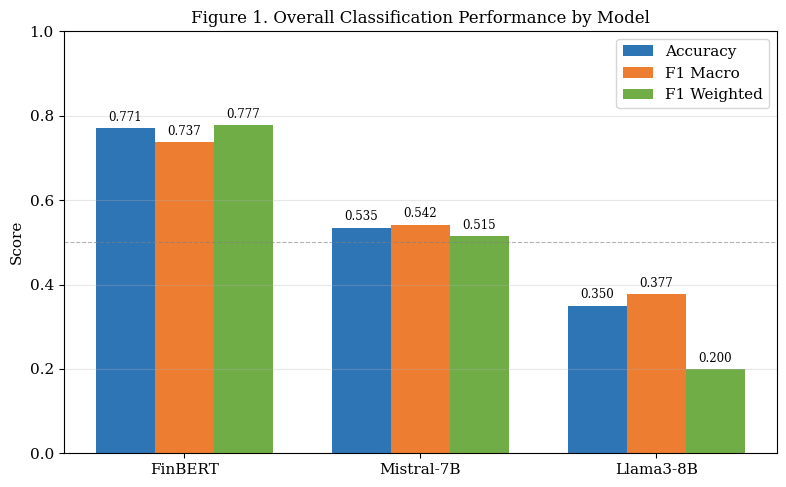

Figure 1 saved


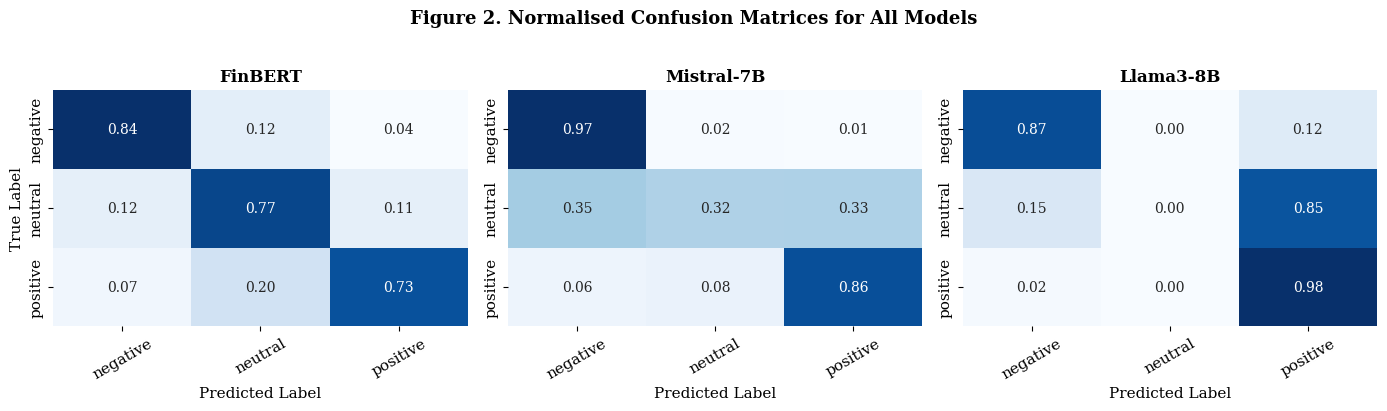

Figure 2 saved


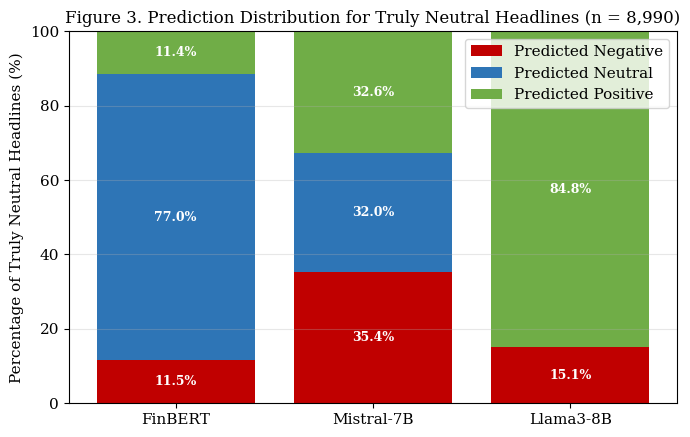

Figure 3 saved


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns

df = pd.read_csv("sentiment_final.csv")
labels = ["negative", "neutral", "positive"]
models = ["FinBERT", "Mistral-7B", "Llama3-8B"]
pred_cols = ["finbert_pred", "mistral_pred", "llama3_pred"]

plt.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.titlesize": 12, "axes.labelsize": 11
})

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(models))
w = 0.25
acc    = [0.7712, 0.5347, 0.3502]
f1mac  = [0.7373, 0.5419, 0.3768]
f1wgt  = [0.7769, 0.5148, 0.2003]

b1 = ax.bar(x - w, acc,   w, label="Accuracy",     color="#2E75B6")
b2 = ax.bar(x,     f1mac, w, label="F1 Macro",     color="#ED7D31")
b3 = ax.bar(x + w, f1wgt, w, label="F1 Weighted",  color="#70AD47")

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Figure 1. Overall Classification Performance by Model")
ax.legend(loc="upper right")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure1_performance.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 1 saved")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, model, col in zip(axes, models, pred_cols):
    cm = confusion_matrix(df["label"], df[col], labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", ax=ax,
                xticklabels=labels, yticklabels=labels,
                cmap="Blues", cbar=False,
                annot_kws={"size": 10})
    ax.set_title(f"{model}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label" if model == "FinBERT" else "")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Figure 2. Normalised Confusion Matrices for All Models", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figure2_confusion.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 2 saved")

fig, ax = plt.subplots(figsize=(7, 4.5))
neutral_df = df[df["label"] == "neutral"]
bar_models = ["FinBERT", "Mistral-7B", "Llama3-8B"]
pred_cols2 = ["finbert_pred", "mistral_pred", "llama3_pred"]

neg_pcts, neu_pcts, pos_pcts = [], [], []
for col in pred_cols2:
    counts = neutral_df[col].value_counts(normalize=True)
    neg_pcts.append(counts.get("negative", 0) * 100)
    neu_pcts.append(counts.get("neutral",  0) * 100)
    pos_pcts.append(counts.get("positive", 0) * 100)

x = np.arange(len(bar_models))
b1 = ax.bar(x, neg_pcts, label="Predicted Negative", color="#C00000")
b2 = ax.bar(x, neu_pcts, bottom=neg_pcts, label="Predicted Neutral", color="#2E75B6")
b3 = ax.bar(x, pos_pcts, bottom=[n+u for n,u in zip(neg_pcts, neu_pcts)],
            label="Predicted Positive", color="#70AD47")

for bars, bottoms in [(b1, [0]*3), (b2, neg_pcts),
                       (b3, [n+u for n,u in zip(neg_pcts, neu_pcts)])]:
    for bar, bot in zip(bars, bottoms):
        h = bar.get_height()
        if h > 4:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bot + h/2, f"{h:.1f}%",
                    ha="center", va="center", fontsize=9,
                    color="white", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(bar_models)
ax.set_ylim(0, 100)
ax.set_ylabel("Percentage of Truly Neutral Headlines (%)")
ax.set_title("Figure 3. Prediction Distribution for Truly Neutral Headlines (n = 8,990)")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure3_neutral_bias.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure 3 saved")

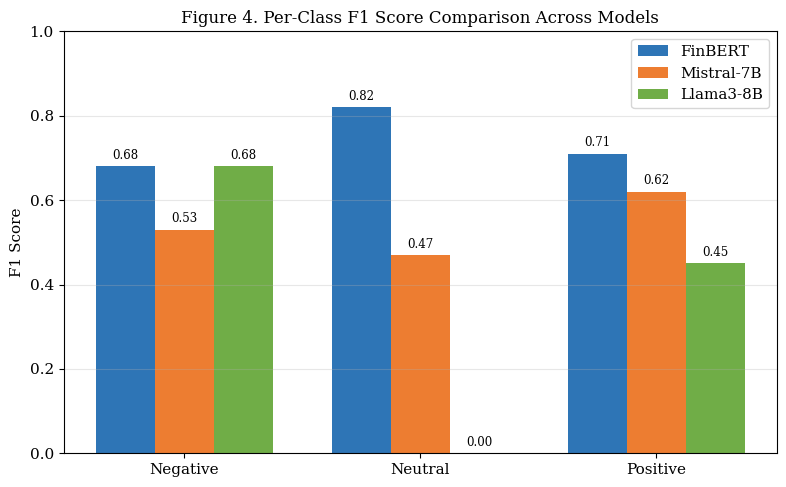

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

classes = ["Negative", "Neutral", "Positive"]
finbert_f1  = [0.68, 0.82, 0.71]
mistral_f1  = [0.53, 0.47, 0.62]
llama3_f1   = [0.68, 0.00, 0.45]

x = np.arange(len(classes))
w = 0.25

b1 = ax.bar(x - w, finbert_f1, w, label="FinBERT",     color="#2E75B6")
b2 = ax.bar(x,     mistral_f1, w, label="Mistral-7B",  color="#ED7D31")
b3 = ax.bar(x + w, llama3_f1,  w, label="Llama3-8B",   color="#70AD47")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1 Score")
ax.set_title("Figure 4. Per-Class F1 Score Comparison Across Models")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure4_perclass_f1.png", dpi=300, bbox_inches="tight")
plt.show()